# for Cadets and Theia
- 不要想着代码适配所有数据集，只要适配自己的需求就可以了
  - Cadets和Theia选取案例不涉及IPC，不考虑所有IPC通信。理论上可以说，但实际上不考虑。
  - 当前数据集在如何将Socket Server和Client对应起来描述一个正常的通信流程也存在问题。
- 先设计一个数据提取方法能够完整地把攻击活动提取出来
  - 在提取地过程中发现问题 --- 解决问题

# 日志解析：舍弃不关心的事件和实体，从关心的日志中提取需要的内容

- 需要考虑Connect和Accept操作（只考虑与Network相关的事件），在这样能够体现出端口扫描行为   0915

In [56]:
# import pickle
import networkx as nx
import pickle

FileName = 'Wholegraph_training_preprocessed_logs_M6-CVE-2017-11882_windows_h1.data' # 由子图提取转为对整图的处理
# TargetNode="c:/users/aalsahee/downloads/msf_2018_8174.rtf"
TargetNode = 'c:/program files/mozilla firefox/firefox.exe_2984'
Path = 'D:\\DataStorge\\IdeaOne\\TargetData\\Formal_Experiment\\ATLAS\\ProGraph\\'+ FileName
with open(Path, 'rb') as f:
    G = pickle.load(f)


In [57]:


AAA = '/device/mup/192.168.223.3/share/msf.exe_3132'
print(AAA,G.nodes[AAA])

print('InEdge:\n')
for node in G.predecessors(AAA):
    
    # if G.nodes[node]['type'] == 'SUBJECT_PROCESS':
        # print(node,G.nodes[node])
    for value in G.get_edge_data(node,AAA).values():
        # if value['Sequence']>=914531:
        print(node,G.nodes[node],value)

print('OutEdge:\n')

for node in G.successors(AAA):
    
    # if G.nodes[node]['type'] == 'SUBJECT_PROCESS':
        # print(node,G.nodes[node])
    for value in G.get_edge_data(AAA,node).values():
        # if value['Sequence']>=914531:
        print(G.nodes[node],node,value)



/device/mup/192.168.223.3/share/msf.exe_3132 {'type': 'process', 'name': '/device/mup/192.168.223.3/share/msf.exe_3132'}
InEdge:

/device/mup/192.168.223.3/share/msf.exe {'type': 'file', 'name': '/device/mup/192.168.223.3/share/msf.exe'} {'type': 'executed', 'Sequence': '30744697'}
c:/windows/system32/csrss.exe_356 {'type': 'process', 'name': 'c:/windows/system32/csrss.exe_356'} {'type': 'fork', 'Sequence': '30744697'}
c:/windows/system32 {'type': 'file', 'name': 'c:/windows/system32'} {'type': 'execute', 'Sequence': '30744697'}
c:/windows/system32 {'type': 'file', 'name': 'c:/windows/system32'} {'type': 'execute', 'Sequence': '30744697'}
c:/windows/system32/sechost.dll {'type': 'file', 'name': 'c:/windows/system32/sechost.dll'} {'type': 'read', 'Sequence': '30744697'}
c:/windows/system32/sechost.dll {'type': 'file', 'name': 'c:/windows/system32/sechost.dll'} {'type': 'execute', 'Sequence': '30744697'}
c:/windows/system32/sechost.dll {'type': 'file', 'name': 'c:/windows/system32/sechos

In [58]:
Node = 'c:/windows/system32/cmd.exe_732'
# print(len(set(G.successors(Node)) & set(G.predecessors(Node))))
# print(len(set(G.successors(Node))),len(set(G.predecessors(Node))))
try: 
    Node
# Node ,G.nodes[Node]
    for node in list(G.successors(Node)):
        print(node,G.nodes[node])
        print(G[Node][node])
    print('-------------------------------')
    for node in list(G.predecessors(Node)):
        print(node,G.nodes[node])
        print(G[node][Node])
except:
    pass

In [ ]:



G.add_edge('c:/program files/microsoft office/office14/winword.exe_360','c:/program files/common files/microsoft shared/equation/eqnedt32.exe_3956',type='write',Sequence = '30744650')
# G.add_edge('c:/program files/common files/microsoft shared/equation/eqnedt32.exe_3956', 'c:/windows/system32/csrss.exe_356',type='write',Sequence = '30744650')
G.add_edge('192.168.223.3','c:/program files/mozilla firefox/firefox.exe_2984',type='EVENT_CONNECT',Sequence = '30731642')  


0

In [60]:
# '终端'概念再Linux中是以文件形式体现的:/dev/tty，代表计算机的输入的输出。
# 参考：<https://cloud.tencent.com/developer/article/1527544>,<https://www.bilibili.com/video/BV1FV411Z7y5/?spm_id_from=333.337.search-card.all.click&vd_source=bfd15b38f2dcd971633f7ff9e3f10ea1>
# 在同一个Bash下，我们在终端进行的输入和输出是不相互影响的,即独立指令之间不会因为终端存在信息的流动。对此需要对该文件作特殊处理。
# Bash:<https://zhuanlan.zhihu.com/p/328045475>
def NoNeedNode(Graph,node):
    Result = False
    FileType = ['file']
    # MatchChar= ['appdata/local/mozilla/firefox','/appdata/roaming/mozilla/firefox/profiles','/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat','/appdata/local/microsoft/windows/temporary internet files/counters.dat']  # 即这些节点不能代表信息流的传递关系，对这些文件的写入和读出都不被考虑。
    # MatchChar= ['/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat','/appdata/local/microsoft/windows/temporary internet files/counters.dat']
    MatchChar = []
    if Graph.nodes[node]['type'] in FileType:
        if any(MChar in Graph.nodes[node]['name'] for MChar in MatchChar):
            Result = True
    return Result

def DontAddNode(Graph,node): # 如果不在主干信息流内，不需要额外添加的文件
    Result = False
    FileType = ['file']
    MatchChar= ['/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat','/appdata/local/microsoft/windows/temporary internet files/counters.dat','c:/users/aalsahee/appdata/roaming/microsoft/windows/recent/customdestinations']  # 即这些节点不能代表信息流的传递关系，对这些文件的写入和读出都不被考虑。
    if Graph.nodes[node]['type'] in FileType and Graph.nodes[node]['name']:
        if any(MChar in Graph.nodes[node]['name'] for MChar in MatchChar):
            Result = True
    return Result

# for node in SubGraph:
#     if SubGraph.nodes[node]['type'] in FileType and SubGraph.nodes[node]['path']:
#         for MChar in MatchChar:
#             if MChar in SubGraph.nodes[node]['path']:
#                 NoNeedNode.append(node)
#                 break
# print(NoNeedNode)
# # SearchGraph.remove_nodes_from(NoNeedNode) # tty不参与网络活动，只会作为内部节点出现。我们认为每次对tty的读写是独立的操作，不会因为不同进程对tty文件的读写而导致信息的交互。
# SubGraph.remove_nodes_from(NoNeedNode) # SubGraph中也移除此类不关心节点

# 序列提取

- 0.错误信息流向纠正（删除干扰节点）
- 1.依据可疑节点确定信息源和信息终点的暴露节点
- 2.依据确定的源和终点还原信息流中关键节点
- 3.长链进程缩减
- 4.依据关键节点补充细节信息（如额外的信息流）

In [61]:
import copy
import time

NodeCount = 0
EdgeCount = 0

GlobalNoNeedNode = {} #key:node value:Label

def  EdgeNodes(G,TargetNode):
    result = 0
    if  G.nodes[TargetNode]['type'] == 'NetworkConnection':# NetFlowObject为边界节点
        # print(3)
        result = 3
        return result
    elif len(list( G.successors(TargetNode))) == 0 or len(list( G.predecessors(TargetNode))) == 0:# 无出边节点为边界节点  流终点
        # print(2)
        result = 1
        return result
    return result
# 边缘节点判断
# def  EdgeNodes(G,TargetNode):
#     result = 0
#     if len(list( G.predecessors(TargetNode))) == 0:# 非进程的无入边节点为边界节点  流起点
#         # print(1)
#         result = 1
#     elif len(list( G.successors(TargetNode))) == 0 :# 无出边节点为边界节点  流终点
#         # print(2)
#         result = 1
#     elif G.nodes[TargetNode]['type'] == 'NetFlowObject':# NetFlowObject为边界节点
#         # print(3)
#         result = 3
#     return result

# 排除Unlink带来的错误因果联系 
# def NoOnlyUnlink(G,node1,node2):
#     if node1 and node2:
#         Edges =  [edge['type'] for edge in G.get_edge_data(node1,node2).values()]
#         if Edges == ['EVENT_UNLINK']:
#             return True
#         else:
#             return False
#     else:
#         return False
def AddExp(Res,node):
    if node not in Res:
        Res.append(node)
    else:
        Res.remove(node)
        Res.append(node)
    return Res
    
def GetSeqInfo(G,node1,node2):
    global EdgeCount
    Edges = G.get_edge_data(node1,node2)
    EdgeCount += len(Edges)
    Seqs = [edge['Sequence'] for edge in Edges.values() if edge['type'] != 'delete']
    return Seqs

def GetNext(Next,G,node0,node1): # node0:Nownode node1:Nextnode
    # print(Next)
    global EdgeCount
    Edges = G.get_edge_data(node0,node1)
    EdgeCount += len(Edges)
    SeqList = [value['Sequence'] for value in Edges.values() if value['Sequence'] >= Next and value['type'] != 'delete']
    if SeqList:
        return min(SeqList) # 大于当前时序的最小值
    return None

def GetPre(Pre,G,node0,node1): # node0:Prenode node1:Nownode
    global EdgeCount
    Edges = G.get_edge_data(node0,node1)
    EdgeCount += len(Edges)
    SeqList = [value['Sequence'] for value in Edges.values() if value['Sequence'] <= Pre and value['type'] != 'delete']
    if SeqList:
        return max(SeqList) # 小于当前时序的最大值
    return None

def Find_Related_Network(G,Node): # 默认Nodelist相互连通,若不互相联通则独立处理
    global GlobalNoNeedNode,NodeCount
    starttime = time.time()
    # global sub_nodes, node_set, G_subgraph, G
    
    # 保存遍历过的节点,防止自环
    # oldNodes = set()
    
    # NodeNumber = 0
    # EdgeNumber = 0

    # 保存遍历过的节点（除NoNeedNode和EdgeNode）
    oldForNode = set()
    oldBackNode = set()

# 使用列表保存时序
    ForExpNode = []
    BackExpNode = []

    # 保存互联网节点
    ForNetNode = set()
    BackNetNode =set()
    
    # 保存遍历路径中的时序信息
    ForNodeSeq = {} # key:node value:sequence
    BackNodeSeq = {}
   
    #保存节点的合法前序和后继
    ForwardNodes = set() # 前驱结果节点
    BackwardNodes = set() # 后继结果节点

    # CandidateNode=set(Nodelist) # 候选节点

    # 准备初始节点的合法前序和后继
    ForwardPool = list(G.successors(Node))
    oldForNode.add(Node) # 保存前向遍历过的节点
    for node in ForwardPool:
        # NodeNumber += 1
        NodeCount += 1
        temp = GetSeqInfo(G,Node,node) # 注意边方向
        # EdgeNumber += len(G.get_edge_data(Node,node))
        if temp:
            Result = EdgeNodes(G,node)
            NoNeedLabel = None
            if node in GlobalNoNeedNode:
                NoNeedLabel = GlobalNoNeedNode[node]
            else:
                GlobalNoNeedNode[node] = NoNeedNode(G,node)
                NoNeedLabel = GlobalNoNeedNode[node]
            if Result == 0 and NoNeedLabel==False:
                ForNodeSeq[node] = min(temp)
                ForwardNodes.add(node) # 时序合法加入遍历序列，只会加入非边缘、非互联网节点
                # oldForNode.add(node)
            elif Result==3 and G.nodes[node]['name'] != '-_0': # 记录互联网节点和暴露节点，这里的暴露节点是符合时序逻辑的
                ForNetNode.add(node)
                ForExpNode = AddExp(ForExpNode,Node)
                # 网络节点可能与数个暴露节点相关，故可能会产生多次遍历。故不加入oldnodes
                
    
    BackwardPool = list(G.predecessors(Node))
   
    oldBackNode.add(Node) # 保存后向遍历过的节点
    for node in BackwardPool:
        # NodeNumber += 1
        NodeCount += 1
        temp = GetSeqInfo(G,node,Node) # 注意边方向
        # EdgeNumber += len(G.get_edge_data(node,Node))
        if temp:
            Result = EdgeNodes(G,node)
            NoNeedLabel = None
            if node in GlobalNoNeedNode:
                NoNeedLabel = GlobalNoNeedNode[node]
            else:
                GlobalNoNeedNode[node] = NoNeedNode(G,node)
                NoNeedLabel = GlobalNoNeedNode[node]
            if Result == 0 and NoNeedLabel==False:
                BackNodeSeq[node] = max(temp)
                BackwardNodes.add(node) # 时序合法加入遍历序列，只会加入非边缘、非互联网节点
                # oldBackNode.add(node)
            elif Result==3 and G.nodes[node]['name'] != '-_0':
                BackNetNode.add(node)
                BackExpNode = AddExp(BackExpNode,Node)
    
                
        
    # BackwardNodes = list(G.predecessors(Node))
    while True:
        
        # 取差集
        NowForWard = [node for node in ForwardNodes if node not in oldForNode]
        NowBackWard = [node for node in BackwardNodes if node not in oldBackNode]
        # print(NowForWard,NowBackWard)
        ForwardNodes = set()
        BackwardNodes = set()

        if len(NowForWard) + len(NowBackWard) == 0:
            break

        # Forward  排除Unlink只对ForwardTracking有效
        for node in NowForWard:	
            oldForNode.add(node) # 保存所有前向遍历过的节点
            
            
            # oldNodes.add(node)
            # ForResultNodes.add(node)
            # Result = EdgeNodes(G,node)
            


            
            # if Result==0 and NoNeedLabel==False:# 非边缘节点,将其时序合法邻居加入遍历序列
                # print(node)
                # print(node,Result,NoNeedNode(G,node))
                
                
            ForwardPool = list(G.successors(node)) # or neighbors # 返回迭代器，用过就归零。互联网节点只会在该集合中出现

            # 排除UNLINK的影响，不承认Unlink带来的信息流
            for nextnode in ForwardPool:
                # NodeNumber += 1
                NodeCount += 1
                temp = GetNext(ForNodeSeq[node],G,node,nextnode)
                if temp:
                    Result = EdgeNodes(G,nextnode)
                    NoNeedLabel = None
                    if nextnode in GlobalNoNeedNode:
                        NoNeedLabel = GlobalNoNeedNode[nextnode]
                    else:
                        GlobalNoNeedNode[nextnode] = NoNeedNode(G,nextnode)
                        NoNeedLabel = GlobalNoNeedNode[nextnode]
                    if Result == 0 and NoNeedLabel==False:
                        if nextnode not in ForNodeSeq:
                            ForNodeSeq[nextnode] = temp
                        else:  # 一个节点可能同时是多个节点的前序/后继，故有此处理
                            ForNodeSeq[nextnode] = min(temp,ForNodeSeq[nextnode])
                        ForwardNodes.add(nextnode) # 时序合法加入遍历序列，只会加入非边缘、非互联网节点
                    elif Result==3 and G.nodes[node]['name'] != '-_0':
                        ForNetNode.add(nextnode)
                        ForExpNode = AddExp(ForExpNode,node)
                        
                            
                # print('successors',list(successors))
                # predecessors = G.predecessors(node)
                # successors = G.successors(node)
                # ForNextNodes=ForNextNodes.union(successors)
                # NetGenCanNode=NetGenCanNode.union(predecessors)
            # elif Result==3 and G.nodes[node]['remoteAddress'] != 'NA':
            #     ForNetNode.add(node)
            #     continue
            
        # Back
        for node in NowBackWard:	
            oldBackNode.add(node) # 保存后向遍历过的节点,这些节点都是非边缘、非网络、非无效信息流的节点
           
            # oldNodes.add(node)
            # Result = EdgeNodes(G,node)
            # BackResultNodes.add(node)
            


            # if Result==0 and NoNeedLabel==False:# 非边缘节点,将其邻居加入遍历序列
                
                # print(node)
                # print(node,Result,NoNeedNode(G,node))
                # successors = G.successors(node) # or neighbors
            BackwardPool = list(G.predecessors(node))
            # print('prenode:',node)
            for prenode in BackwardPool:
                # print(prenode)
                # NodeNumber += 1
                NodeCount += 1
                temp = GetPre(BackNodeSeq[node],G,prenode,node)
                if temp:
                    Result = EdgeNodes(G,prenode)
                    NoNeedLabel = None
                    if prenode in GlobalNoNeedNode:
                        NoNeedLabel = GlobalNoNeedNode[prenode]
                    else:
                        GlobalNoNeedNode[prenode] = NoNeedNode(G,prenode)
                        NoNeedLabel = GlobalNoNeedNode[prenode]
                    if Result == 0 and NoNeedLabel==False:
                        if prenode not in BackNodeSeq:
                            BackNodeSeq[prenode] = temp
                        else:
                            BackNodeSeq[prenode] = max(temp,BackNodeSeq[prenode])
                        BackwardNodes.add(prenode)
                    elif Result==3 and G.nodes[node]['name'] != '-_0':
                        BackNetNode.add(prenode)
                        BackExpNode = AddExp(BackExpNode,node)


                # print('predecessors',list(predecessors))
                # NetGenCanNode=NetGenCanNode.union(successors)
                # predecessors = G.predecessors(node)
                # BackNextNodes=BackNextNodes.union(predecessors)
            # elif Result==3 and G.nodes[node]['remoteAddress'] != 'NA':
            #     BackNetNode.add(node)
                
        

        # print(len(ForwardNodes),len(BackwardNodes))
    # for netnode in ForNetNode:
    #     for nbnode in G.predecessors(netnode):
    #         if nbnode in oldForNode:
    #             ForExpNode.add(nbnode)
    # for netnode in BackNetNode:
    #     for nbnode in G.successors(netnode):
    #         if nbnode in oldBackNode:
    #             BackExpNode.add(nbnode)
    
    print('遍历边数-暴露节点确定：',EdgeCount)
    print('遍历节点数-暴露节点确定：',NodeCount)
    print('耗时：',time.time()-starttime)

    return  ForNetNode,BackNetNode,ForExpNode,BackExpNode

In [62]:
ForNetNode,BackNetNode,ForwardConnectionNode,BackConnectionNode = Find_Related_Network(G,TargetNode)  # 找到与可以节点有关的互联网节点

# B53501B6-0200-0000-0000-000000000020


遍历边数-暴露节点确定： 13455
遍历节点数-暴露节点确定： 5810
耗时： 0.047513484954833984


In [63]:
NetNode = ForNetNode.union(BackNetNode)  # 
print('网络节点',ForNetNode,BackNetNode)
print('暴露节点：',ForwardConnectionNode,BackConnectionNode)
# # 互联网节点的邻居节点为暴露节点
# ExposureNode=[]
# for node in NetNode:
#     ExposureNode.extend(list(G.predecessors(node)) + list(G.successors(node)))


# 移除互联网节点，只保留暴露节点以进行信息流还原
SearchGraph = copy.deepcopy(G)
SearchGraph.remove_nodes_from(list(NetNode))


# # 筛选与目标节点有信息流的暴露节点，极端情况下可能有些节点即是上游节点又是下游节点
# BackConnectionNode=set() # 可疑节点上游暴露节点
# ForwardConnectionNode=set() # 可疑节点下游暴露节点
# # test2=[]
# for node in set(ExposureNode):
#     # if nx.has_path(SearchGraph,node,TargetNode) or node == TargetNode:
#     if PathDetect(SearchGraph,node,TargetNode) != None:
#         BackConnectionNode.add(node)
# #     if nx.has_path(SubGraph,node,TargetNode) or node == TargetNode:
# #         test2.append(node)
#     if nx.has_path(SearchGraph,TargetNode,node) or node == TargetNode:
#         ForwardConnectionNode.add(node)
# ConnectionNode =  BackConnectionNode .union( ForwardConnectionNode) # 暴露节点集合
# print(BackConnectionNode,ForwardConnectionNode) # 数据可视化
# len(ConnectionNode),len(BackConnectionNode),len(ForwardConnectionNode)

网络节点 {'35.165.209.195', '72.21.91.29', '172.217.4.99', '216.58.216.197', '192.168.223.128', '149.165.180.35', '172.217.0.4', '172.217.6.110', '52.11.104.45', '54.69.134.102', '54.201.132.73', '52.25.25.113', '74.125.124.189', '172.217.6.13', '216.58.192.174', '149.165.180.19', '216.58.192.142', '52.85.117.148', '172.217.4.35', '216.58.192.206', '172.217.4.106', '172.217.8.170', '205.185.216.10', '52.85.117.46', '172.217.6.99', '172.217.1.37', '172.217.5.14', '216.58.216.206', '192.168.223.3', '172.217.6.97', '172.217.1.46', '172.217.8.206'} {'192.168.223.3'}
暴露节点： ['c:/program files/mozilla firefox/firefox.exe_2984', '/device/mup/192.168.223.3/share/msf.exe_3132', '/device/mup/192.168.223.3/share/msf.exe_3432', '/device/mup/192.168.223.3/share/msf.exe_2060', 'c:/users/aalsahee/payload.exe_2820', 'c:/python27/python.exe_2408'] ['c:/program files/mozilla firefox/firefox.exe_2984']


In [64]:
len(ForwardConnectionNode),len(BackConnectionNode)

(6, 1)

In [65]:
# 1.找到与信息源节点两跳以内的，被读写的非进程节点
from collections import Counter
def Get2_hopSubGraph(G,node): # 提取目标节点2-hop邻居：这些邻居都与目标节点至少单向可达
    
    ResultNodes = set() # 结果节点
    TwoHopCand = set()
    # 1-hop
    for succ_node in G.successors(node): # 后继
        if G.nodes[succ_node]['type'] == 'process':
            TwoHopCand.add(succ_node)
        elif G.has_edge(succ_node,node):  # 双向关系
            ResultNodes.add(succ_node)

    for pred_node in G.predecessors(node): # 前驱
        if G.nodes[pred_node]['type'] == 'process':
            TwoHopCand.add(pred_node)
        elif G.has_edge(node,pred_node):  # 双向关系
            ResultNodes.add(pred_node)

    # 2-hop
    for TwoHopNode in TwoHopCand:
        # print(TwoHopNode)
        for succ_node in G.successors(TwoHopNode): # 后继
            # print('succ:',succ_node,G.nodes[succ_node])
            if G.has_edge(succ_node,TwoHopNode):
                ResultNodes.add(succ_node)
        for pred_node in G.predecessors(TwoHopNode): # 前驱
            # print('pred:',pred_node,G.nodes[pred_node])
            if G.has_edge(TwoHopNode,pred_node):
                ResultNodes.add(pred_node)
        # print('\n')
    # G_subgraph = G.subgraph(ResultNodes).copy()# 子图包含指定的节点及其之间的边，不涉及其他节点
    return  ResultNodes
            

# Get2_hopSubGraph(SearchGraph,'2E7BB2B4-E953-0FDF-1308-2259C75DC8F9')

TwoHopGraphNonprocessNode = []
Total = []
for node in BackConnectionNode:
    TwohopGraNodes = Get2_hopSubGraph(SearchGraph,node)
    TwoHopGraphNonprocessNode.extend(TwohopGraNodes)

Result = Counter(TwoHopGraphNonprocessNode)



# 2.筛选与参数 x 个相同Cmdline的进程有读写交互的 非进程实体,并统计其对应的进程Cmdline和读写交互次数
# x = 10 # 在此将参数设置为10
x = 4
CandidateFile = []

PublicNodes = {}

for key in Result:
    if Result[key] >= x:
        CandidateFile.append(key)
        # print(key,G.nodes[key])
for Cand in CandidateFile:
    # print(Cand,G.nodes[Cand],'******----')
    SuccCmdline = []
    PredCmdline = []
    for node in SearchGraph.successors(Cand):
        SuccCmdline.append(G.nodes[node]['name'].split('_')[0])
    for node in SearchGraph.predecessors(Cand):
        PredCmdline.append(G.nodes[node]['name'].split('_')[0])
    # print(Counter(SuccCmdline + PredCmdline))
    FinalCmdline = [CL for CL in SuccCmdline if CL in PredCmdline]
    print(Cand,'\n',Counter(FinalCmdline))
    for key,value in  Counter(FinalCmdline).items():
        if value >= x:
            if Cand not in PublicNodes:
                PublicNodes[Cand] = [key]
            else:
                PublicNodes[Cand].append(key)

print(PublicNodes)

# 3.实现一个不考虑PublicNodes对应Cmdline进程的过滤函数(在ForwardTracking时,只需要对当前节点以及当前节点的下一个节点做判断即可)
def PublicNodesFliter(G,nodesrc,nodesnk,PublicNodes):
    if nodesrc in PublicNodes:
        if G.nodes[nodesnk]['type'] == 'process':
            if G.nodes[nodesnk]['name'].split('_')[0] in PublicNodes[nodesrc]:
                return None
    return True

{}


In [66]:

def GetMarkSequence(SubGraph,SrcNode):
    MarkSequence = '99999999'  # 第一次暴露时间
    for edge in list(SubGraph.in_edges(SrcNode,data=True)) + list(SubGraph.out_edges(SrcNode,data=True)): # 涉及到NetFlowObject，使用SubGraph
        if SubGraph.nodes[edge[1]]['type'] == 'NetworkConnection' or SubGraph.nodes[edge[0]]['type'] == 'NetworkConnection':
            # print(edge)
            if edge[2]['Sequence'] < MarkSequence:
                MarkSequence = edge[2]['Sequence']
    return MarkSequence
# ConnectionNode = BackConnectionNode + ForwardConnectionNode

def ReverseGetMarkSequence(SubGraph,SrcNode):
    MarkSequence = '0'  # 第一次暴露时间
    for edge in list(SubGraph.in_edges(SrcNode,data=True)) + list(SubGraph.out_edges(SrcNode,data=True)): # 涉及到NetFlowObject，使用SubGraph
        if SubGraph.nodes[edge[1]]['type'] == 'NetworkConnection' or SubGraph.nodes[edge[0]]['type'] == 'NetworkConnection':
            # print(edge)
            if edge[2]['Sequence'] > MarkSequence:
                MarkSequence = edge[2]['Sequence']
    return MarkSequence

# DstNodes = ForwardConnectionNode
# SrcNodes = list(reversed(BackConnectionNode))

In [67]:

# Forward

def ForTimeSpace(ForNodeRecord,nexttime,node):
    Result = True
    # Next = GetNext(nexttime,Graph,Src,node)
    if node in ForNodeRecord and ForNodeRecord[node] <= nexttime:
            Result = False
    return Result

def NoSuccessor(ForNodeRecord,Graph,node,time):
    Result = []
    for n in Graph.successors(node):
        if NoNeedNode(Graph,n)==False and PublicNodesFliter(Graph,node,n,PublicNodes):
        # if NoNeedNode(Graph,n)==False:
            nt = GetNext(time,Graph,node,n)
            if nt:
                if ForTimeSpace(ForNodeRecord,nt,n):
                    Result.append([n,nt]) # 返回所有可继续遍历的节点
            # break
    return Result




def GetForwardKeyNode(Graph, Src,ForNodeRecord,Next): 
    ForNodeRecord[Src] = Next
    # 结束条件
    Judge = NoSuccessor(ForNodeRecord,Graph,Src,Next)
    if len(Judge) == 0:
        return 

    # 时序 + 拓扑记录遍历节点
    for [node,time] in Judge:
                GetForwardKeyNode(Graph, node, ForNodeRecord,time)
   
# Backward

def BackTimeSpace(BackNodeRecord,backtime,node):
    Result = True
    # Next = GetNext(nexttime,Graph,Src,node)
    if node in BackNodeRecord and BackNodeRecord[node] >= backtime:
            Result = False
    return Result

def NoPredecessor(BackNodeRecord,Graph,node,time,Cache):
    Result = []
    for n in Graph.predecessors(node):
        if NoNeedNode(Graph,n)==False and PublicNodesFliter(Graph,n,node,PublicNodes):
        # if NoNeedNode(Graph,n)==False:
            nt = GetPre(time,Graph,n,node)
            if nt:
                if n in Cache:
                    if nt >= Cache[n][n]:
                        BackNodeRecord.update(Cache[n])
                if BackTimeSpace(BackNodeRecord,nt,n):
                    Result.append([n,nt]) # 返回所有可继续遍历的节点
                # break
    return Result


# ForNodeRecord = {} # node:timestamp
def GetBackwardKeyNode(Graph, Src,BackNodeRecord,Pre,Cache): 
    BackNodeRecord[Src] = Pre
    # 结束条件
    Judge = NoPredecessor(BackNodeRecord,Graph,Src,Pre,Cache)
    if len(Judge) == 0:
        return 
    # 时序 + 拓扑记录遍历节点
    for [node,time] in Judge:
        GetBackwardKeyNode(Graph, node, BackNodeRecord,time,Cache)

In [68]:
DstNodes = list(ForwardConnectionNode)
SrcNodes = list(reversed(BackConnectionNode))
def GetWanted(ForNodeRecord,BackNodeRecord):
    WantedNodes = []
    for node in ForNodeRecord:
        if node in BackNodeRecord and ForNodeRecord[node] < BackNodeRecord[node]:
            WantedNodes.append(node)
    return WantedNodes

starttime = time.time()

# ForwardCache = {}
BackwardCahce = {}

WantedNodes = []
for Srcnode in SrcNodes:
    if Srcnode in WantedNodes:
        # print(Srcnode)
        continue
    MarkSequence = GetMarkSequence(G,Srcnode) # 获取信息源连接互联网的时间
    Temp = copy.deepcopy(DstNodes)    
    ForNoderecord = {}
    GetForwardKeyNode(SearchGraph, Srcnode,ForNoderecord,MarkSequence)
    # ForwardCache[Srcnode] = ForNoderecord
    while Temp != []: # 一个Src到所有Dst的路径
        Dstnode = Temp[0]
        BackNoderecord = {}
        if Dstnode not in WantedNodes:
            MarkSequence = ReverseGetMarkSequence(G,Dstnode)
            GetBackwardKeyNode(SearchGraph,Dstnode,BackNoderecord,MarkSequence,BackwardCahce)
            BackwardCahce[Dstnode] = BackNoderecord
            WantedNodes = WantedNodes + GetWanted(ForNoderecord,BackNoderecord)
        Temp.remove(Dstnode)

print('可疑活动还原时长：',time.time()-starttime)
Result = set(WantedNodes)

可疑活动还原时长： 0.12729454040527344


In [69]:
Result

{'/device/mup/192.168.223.3/share/msf.exe_3132',
 '/device/mup/192.168.223.3/share/msf.exe_3432',
 'c:/program files/common files/microsoft shared/equation/eqnedt32.exe_3956',
 'c:/program files/microsoft office/office14/winword.exe_360',
 'c:/program files/mozilla firefox/firefox.exe_2984',
 'c:/python27/python.exe_2408',
 'c:/users/aalsahee/appdata/local/microsoft/windows/temporary internet files/counters.dat',
 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2',
 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/38f4bbf0d8e26db2658e59760d2c74a81c4fdbcd',
 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/60059d769d21ab40f945a158c5cfd97c960b626c',
 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/7007665dbfb619bb8b780f998401fadf70653272',
 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/8fc79

In [70]:
# # 起始的关键节点一定是进程，在攻击活动中一定处于骨干地位。优先选取信息流入的进程。
# # 基于时序的信息流还原，由于是从该信息源头进行信息流还原，因此还原过程是单向的。
# # 再还原后的节点中发现‘关键节点’：直接参与信息流通的节点
# # 基于筛选出的关键节点再做针对‘获取信息’操作的补充：基于信息源和信息终点确定关键节点筛选方法。
# # SearchGraph移除了NetFlowObject、tty文件、DELETE操作这些会影响信息流还原的干扰因素
# FinalResult = set()
# # 获取关键节点
# # ResultNode=set()
# # NextNode = set([SrcNode]) # 每轮循环的起点，从信息源起点开始遍历到信息终点
# for Src in SrcNodes: # 所有源节点和目的节点配对，发现关键节点。
#     for Dst in DstNodes:
#         # if Src in  FinalResult and Dst in FinalResult:
#         #     continue
#         print(Src,'To',Dst,'\n')
#         # ResultNode = ResultNode.union(GetKeyNodes(SearchGraph,G,Src,Dst))
#         FinalResult = FinalResult.union(GetKeyNodes(SearchGraph,G,Src,Dst))

        
# len(FinalResult),FinalResult

# print('可疑活动还原遍历节点数：',NodeCounts)
# print('可疑活动还原遍历边数：',EdgeCounts)
print('可疑活动还原遍历边数：',EdgeCount)
print('可疑活动还原遍历节点数：',NodeCount)
print('可疑活动还原时长：',time.time()-starttime)

可疑活动还原遍历边数： 64130
可疑活动还原遍历节点数： 5810
可疑活动还原时长： 0.1555025577545166


In [71]:
FinalResult = Result
for node in FinalResult:
    print(node,G.nodes[node])

KeyGraph = G.subgraph(FinalResult).copy()
removedNode = []
for node in KeyGraph.nodes:
    if list(KeyGraph.successors(node)) == list(KeyGraph.predecessors(node)) and len(list(KeyGraph.successors(node))) == 1:
      removedNode.append(node)
KeyGraph.remove_nodes_from(removedNode)
for node in removedNode:
   print(node)


c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/safebrowsing/testexcept-flashsubdoc-simple.sbstore {'type': 'file', 'name': 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/safebrowsing/testexcept-flashsubdoc-simple.sbstore'}
c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/abe2a10d1b5f2f66a4422988e6f00ab75897f65c {'type': 'file', 'name': 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/abe2a10d1b5f2f66a4422988e6f00ab75897f65c'}
c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/9da08084794dc156b84954591bfbe79195d83ec0 {'type': 'file', 'name': 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/9da08084794dc156b84954591bfbe79195d83ec0'}
c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/bb95d0607349d05725d5fe01d4fb300e319072ad {'type': 'file',

('c:/users/aalsahee/appdata/local/temp', {'type': 'file', 'name': 'c:/users/aalsahee/appdata/local/temp'}) 4
('c:/users/aalsahee/payload.exe', {'type': 'file', 'name': 'c:/users/aalsahee/payload.exe'}) 3
('c:/users/aalsahee/downloads/msf.rtf', {'type': 'file', 'name': 'c:/users/aalsahee/downloads/msf.rtf'}) 4
('c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2', {'type': 'file', 'name': 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2'}) 4
('c:/program files/microsoft office/office14/winword.exe_360', {'type': 'process', 'name': 'c:/program files/microsoft office/office14/winword.exe_360'}) 5
('/device/mup/192.168.223.3/share/msf.exe_3132', {'type': 'process', 'name': '/device/mup/192.168.223.3/share/msf.exe_3132'}) 10
('c:/users/aalsahee/appdata/locallow/microsoft/cryptneturlcache/content/94308059b57b3142e455b38a6eb92015', {'type': 'file', 'name': 'c:/users/aalsahee/appdata/locallow/microsoft/cryptneturlcache/content/9430

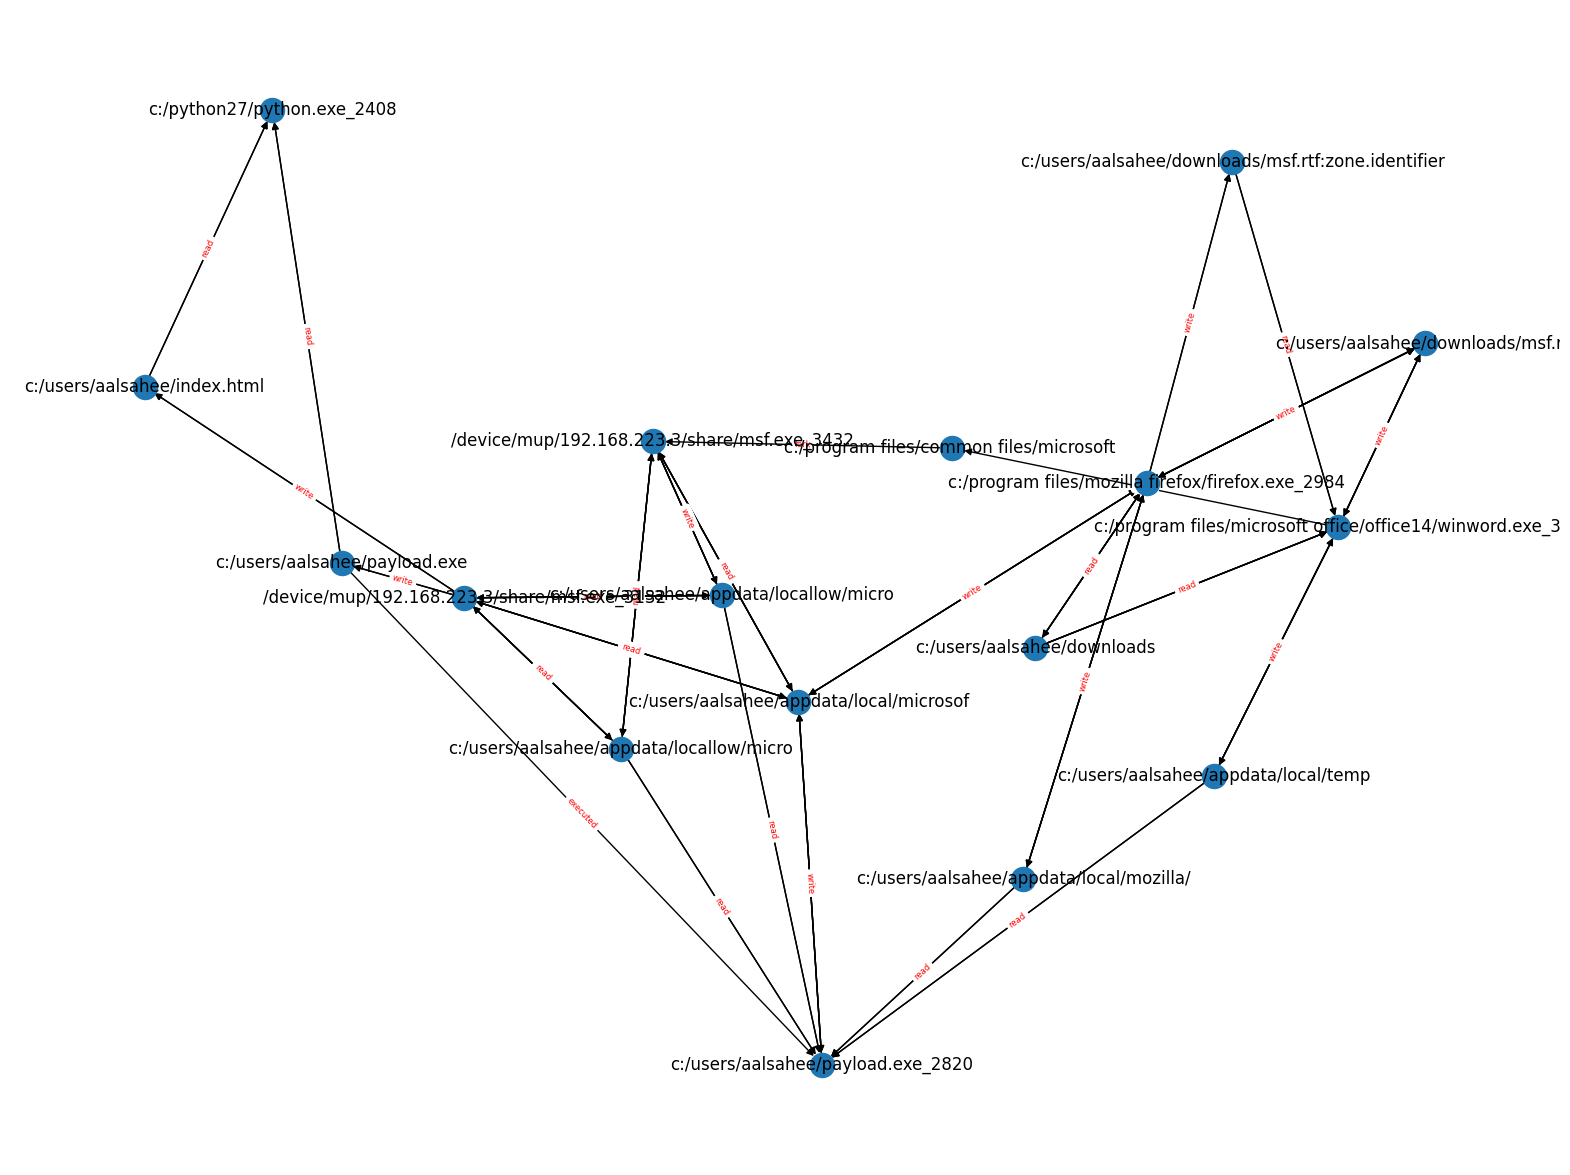

M6-CVE-2017-11882_windows_h1.data


In [72]:
# len(FinalResult),FinalResult


# 数据可视化


# import matplotlib
import matplotlib.pyplot as plt
# TestGraph = SearchGraph.subgraph(ResultNode)

for node in KeyGraph.nodes(data=True):
    print(str(node),KeyGraph.out_degree(node[0]))
    
Edgesssss=list(KeyGraph.edges(data=True))
SortedEdge = Edgesssss.sort(key = lambda x:x[2]['Sequence'])

for edge in Edgesssss:
    print(str(edge))
nodeLabels = {}
for node in KeyGraph.nodes:
    for node in KeyGraph.nodes:
        if len(KeyGraph.nodes[node]['name'])<= 70:
            nodeLabels[node] = KeyGraph.nodes[node]['name']
        else:
            nodeLabels[node] = KeyGraph.nodes[node]['name'][:40]
EdgeLabels = {}
for edge in KeyGraph.edges(data=True):
    EdgeLabels[(edge[0],edge[1])] = edge[2]['type']
nodes_to_draw = KeyGraph.nodes
edges_to_draw = KeyGraph.edges
# pos = nx.spring_layout(TestGraph,k = 100)
# pos = nx.spring_layout(TestGraph)
pos = nx.spring_layout(KeyGraph,k=1.0)
plt.figure(figsize=(20,15))
nx.draw_networkx_nodes(KeyGraph, pos,
                       nodelist=nodes_to_draw,)

# 画边
nx.draw_networkx_edges(KeyGraph, pos,
                       edgelist=edges_to_draw,)

# 画标签
nx.draw_networkx_edge_labels(KeyGraph, pos, edge_labels=EdgeLabels, font_color='red', font_size=6)
nx.draw_networkx_labels(KeyGraph, pos, font_size=12, labels=nodeLabels,font_color='black') 
plt.axis("off")
plt.show()





InName = FileName.split('_')
if 'py' in InName:
    InName = InName[-4] + '_' + InName[-3] + '_' + InName[-2] + '_' +InName[-1]
else:
    InName = InName[-3] + '_' + InName[-2] + '_' +InName[-1]
print(InName)
with open("D:\\DataStorge\\IdeaOne\\TargetData\\Formal_Experiment\\ATLAS\\\\Key_Act\\{y}".format(y=InName),'wb') as f:
    pickle.dump(KeyGraph,f)


In [73]:
def GetMark(Nodes):
    Res = '99999999'
    for node in Nodes:
        # print(GetMarkSequence(G,node))
        if Res> GetMarkSequence(G,node):
            Res = GetMarkSequence(G,node)
    return Res


In [74]:

# 补充信息流活动细节（中间节点的文件读取和网络连接）,查询节点入边，考虑Sequence
# InOperation=['EVENT_READ','EVENT_EXECUTE','EVENT_MMAP','EVENT_FORK','EVENT_CLONE','EVENT_UNIT']
# OutOperation=['EVENT_WRITE','EVENT_FORK','EVENT_CLONE','EVENT_UNIT']
# NetObject = 'NetFlowObject'
import Sensitive

MarkSequence  = GetMark(SrcNodes) # 获取最早暴露时间作为过滤依据
print(MarkSequence)
# Indector = 10 # 超过此数值为基础信息节点
# PublicSrcType = ['.so','.dll','.so.1','.ttf','.cache']
# CaredStrs = Sensitive.SenDirLinux + Sensitive.SenInsLinux
DonotCareType = ['process']
RemoveNode4PublicSrc = set()
# 补充信息传播路径信息,
AddedNodes = set()
for node in FinalResult: 
    # 在补充信息时，信息输入只考虑敏感文件的读取，信息输出不作限制。取消公共信息节点移除环节
    # # 公共信息节点移除
    # if len(list(G.successors(node))) == 0: # 信息终点
    #     if len(list(G.predecessors(node))) > Indector and G.nodes[node]['type'] in PublicSrcType: # 信息源
    #         RemoveNode4PublicSrc.add(node)
    # elif len(list(G.predecessors(node))) == 0: # 信息源
    #     if len(list(G.successors(node))) > Indector and G.nodes[node]['type'] in PublicSrcType: # 信息终点
    #         RemoveNode4PublicSrc.add(node)
    # 互联网节点
    for edge in G.out_edges(node,data=True): # 在SubGraph上获取信息
        if edge[2]['Sequence'] >=  MarkSequence: # 检验时序
            # print(1)
            if (G.nodes[edge[1]]['type'] not in DonotCareType) and DontAddNode(G,edge[1]) == False and edge[2]['type'] != 'delete': # and NoNeedNode(G,edge[1]) == False:# 不考虑信息流方向不同的进程路径。
                print('out:',edge)
                AddedNodes.add(edge[1]) 
    # 互联网节点 + 文件节点、进程节点（此时只考虑直系父亲节点，不做追溯，因为默认其与可疑节点信息源无关）
    for edge in G.in_edges(node,data=True): # 在SubGraph上获取信息,入边只考虑敏感文件
        if edge[2]['Sequence'] >= MarkSequence: # 检验时序
            # print(2)
            if G.nodes[edge[0]]['type'] not in DonotCareType:
                
                try:
                    StrJudge = any(Cstr in G.nodes[edge[0]]['name'] for Cstr in Sensitive.SenDirWindows)
                except:
                    StrJudge = False
                # try:
                #     LineJudge = any(Cline in edge[2]['CmdLine'] for Cline in Sensitive.SenInsLinux)
                # except:
                #     LineJudge = False

                if G.nodes[edge[0]]['type'] == 'NetFlowObject':
                    StrJudge = True
                    
                if  StrJudge  and DontAddNode(G,edge[0]) == False:
                    print('in:',edge)
                    AddedNodes.add(edge[0])

# 根据节点提取出活动子图
ResultNode = FinalResult.union(AddedNodes) - RemoveNode4PublicSrc
print(len(ResultNode))
print(ResultNode)
TestGraph = G.subgraph(ResultNode).copy()

30731642
out: ('c:/program files/microsoft office/office14/winword.exe_360', 'c:/users/aalsahee/appdata/local/temp', {'type': 'write', 'Sequence': '30744631'})
out: ('c:/program files/microsoft office/office14/winword.exe_360', 'c:/users/aalsahee/appdata/local/temp', {'type': 'write', 'Sequence': '30744631'})
out: ('c:/program files/microsoft office/office14/winword.exe_360', 'c:/users/aalsahee/appdata/roaming/microsoft/templates/normal.dotm', {'type': 'write', 'Sequence': '30744631'})
out: ('c:/program files/microsoft office/office14/winword.exe_360', 'c:/users/aalsahee/appdata/roaming/microsoft/templates/normal.dotm', {'type': 'write', 'Sequence': '30744631'})
out: ('c:/program files/microsoft office/office14/winword.exe_360', 'c:/users/aalsahee/appdata/local/microsoft/windows/temporary internet files/content.word/~wrs{5ae9c85e-0eea-4c21-b2c0-7e4b9220d669}.tmp', {'type': 'write', 'Sequence': '30744631'})
out: ('c:/program files/microsoft office/office14/winword.exe_360', 'c:/users/aa

In [75]:
# 增加一个公共信息源移除机制，一些被不同进程普遍使用的，只读不写且非敏感文件的公共文件。只读不写代表与此次外部信息流无关
removedNode = []
for node in TestGraph.nodes:
    if list(TestGraph.successors(node)) == list(TestGraph.predecessors(node)) and len(list(TestGraph.successors(node))) == 1:
      removedNode.append(node)
TestGraph.remove_nodes_from(removedNode)
for node in removedNode:
   print(node)

c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/693d2f272165da61e1e3e4d519d33eb71fce092e
c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/8c8ef748eb820090ef4a554922953eba9f9db398
c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/safebrowsing/test-flashallow-simple.pset
c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/1cabdc2d493bf69574b199d1094a275de368aa22
c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/9772bb6c637e0f796370574b8660f9147ec44c01
c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/e7e7415bd282eb447c893ba47d33be440cd9c5bd
c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/883d7d42d385e179b0b5107c5a41efb781b4d5dd
c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/9c41d5c5cd034162

('c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/doomed', 'c:/program files/mozilla firefox/firefox.exe_2984', {'type': 'read', 'Sequence': '28995747'})
('c:/program files/mozilla firefox/firefox.exe_2984', 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/doomed', {'type': 'delete', 'Sequence': '28995747'})
('c:/program files/mozilla firefox/firefox.exe_2984', 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/doomed', {'type': 'delete', 'Sequence': '28995747'})
('c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2', 'c:/program files/mozilla firefox/firefox.exe_2984', {'type': 'read', 'Sequence': '28995747'})
('c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/doomed', 'c:/program files/mozilla firefox/firefox.exe_2984', {'type': 'read', 'Sequence': '28995748'})
('c:/program files/mozilla firefox/firefox.exe_2984', 'c:/users/aals

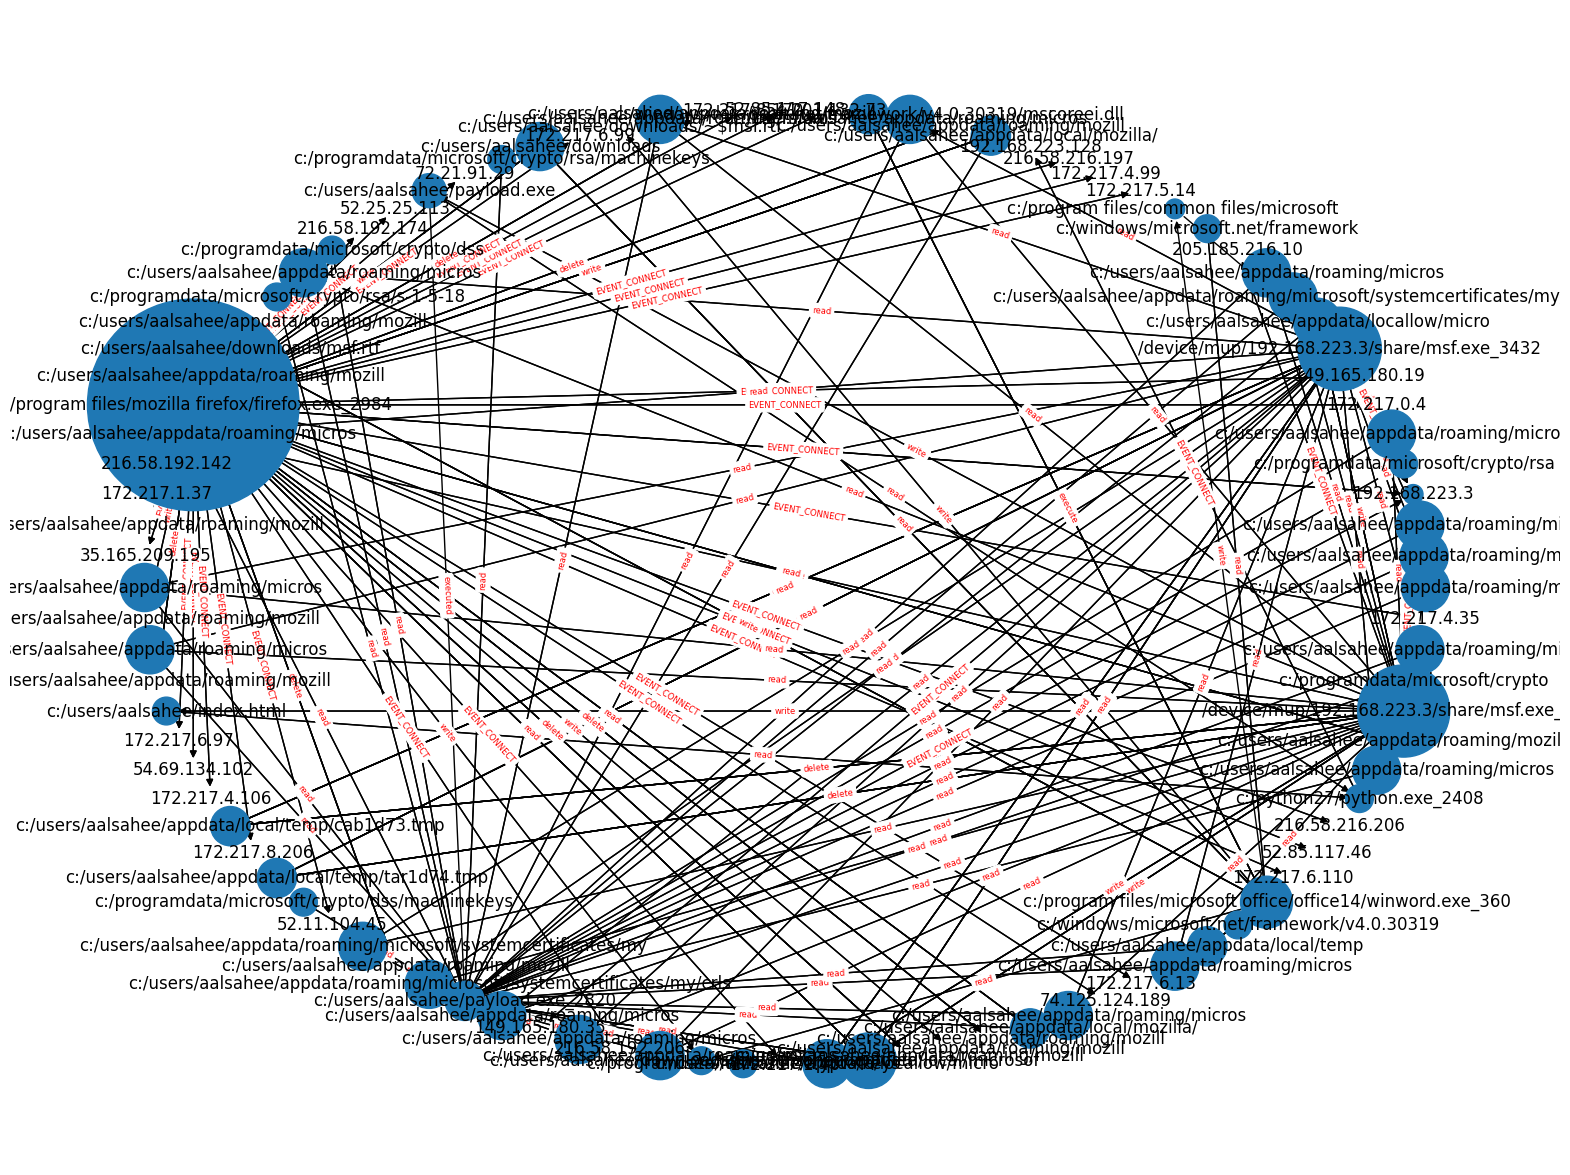

In [76]:
# 数据可视化
import numpy as np

# import matplotlib
import matplotlib.pyplot as plt
# TestGraph = SearchGraph.subgraph(ResultNode)

nodeLabels = {}
for node in TestGraph.nodes:
    if len(TestGraph.nodes[node]['name'])<= 70:
        nodeLabels[node] = TestGraph.nodes[node]['name']
    else:
        nodeLabels[node] = TestGraph.nodes[node]['name'][:40]
        
Edgesssss=list(TestGraph.edges(data=True))
SortedEdge = Edgesssss.sort(key = lambda x:x[2]['Sequence'])

for edge in Edgesssss:
    print(str(edge))

EdgeLabels = {}
for edge in TestGraph.edges(data=True):
    EdgeLabels[(edge[0],edge[1])] = edge[2]['type']




weights = [TestGraph.out_degree(node) for node in TestGraph.nodes]

scaled_weights = np.array(weights) * 200

nodes_to_draw = TestGraph.nodes
edges_to_draw = TestGraph.edges
# pos = nx.spring_layout(TestGraph,k = 100)
pos = nx.circular_layout(TestGraph)
plt.figure(figsize=(20,15))
nx.draw_networkx_nodes(TestGraph, pos,node_size=scaled_weights,
                       nodelist=nodes_to_draw,)

# 画边
nx.draw_networkx_edges(TestGraph, pos,
                       edgelist=edges_to_draw,)

# 画标签
nx.draw_networkx_edge_labels(TestGraph, pos, edge_labels=EdgeLabels, font_color='red', font_size=6)
nx.draw_networkx_labels(TestGraph, pos, font_size=12, labels=nodeLabels,font_color='black') 
plt.axis("off")
# plt.savefig("D:\\DataStorge\\IdeaOne\\TargetData\\ATLAS\\FinalResult\\{}.png".format(FileName))
plt.show()





In [77]:
# for node in   TestGraph.successors('c:/python27/lib/os.pyc'):
#     print(node)

# for node in   TestGraph.predecessors('c:/python27/lib/os.pyc'):
#     print(node)

# list(TestGraph.successors('c:/python27/lib/os.pyc')) == list(TestGraph.predecessors('c:/python27/lib/os.pyc'))


In [78]:
# InName = FileName.split('_')
# if 'py' in InName:
#     InName = InName[-4] + '_' + InName[-3] + '_' + InName[-2] + '_' +InName[-1]
# else:
#     InName = InName[-3] + '_' + InName[-2] + '_' +InName[-1]
# print(InName)
# with open("D:\\DataStorge\\IdeaOne\\TargetData\\Formal_Experiment\\ATLAS\\\\Sus_Act\\{y}".format(y=InName),'wb') as f:
#     pickle.dump(TestGraph,f)